# BUS 212A — Lecture 19 Notebook
## Workflow Structure

This notebook continues Lecture 18.

What did we learn from the last lecture? Even a small, controlled change can meaningfully improve a simple model. Today, we build on that idea and practice the full ML workflow from start to finish.

We want:
1. clear structure
2. reproducibility
3. controlled iteration
4. interpretable comparisons

You can use this lecture as a practice exam for Midterm 2.

Let's import data again.

In [ ]:
from pathlib import Path

In [ ]:
def load_california_housing_df():
    local_candidates = [
        Path("housing.csv"),
        Path("datasets/housing/housing.csv"),
        Path("/content/housing.csv"),
        Path("/content/datasets/housing/housing.csv"),
    ]

    for path in local_candidates:
        if path.exists():
            df = pd.read_csv(path)
            return df, f"Loaded local file: {path}"

    # Try sklearn
    try:
        from sklearn.datasets import fetch_california_housing
        bunch = fetch_california_housing(as_frame=True)
        df = bunch.frame.copy()
        # Rename columns to match the more lecture-friendly names used in the book
        rename_map = {
            "MedInc": "median_income",
            "HouseAge": "housing_median_age",
            "AveRooms": "avg_rooms",
            "AveBedrms": "avg_bedrooms",
            "Population": "population",
            "AveOccup": "avg_occupancy",
            "Latitude": "latitude",
            "Longitude": "longitude",
            "MedHouseVal": "median_house_value"
        }
        df = df.rename(columns=rename_map)
        return df, "Loaded via sklearn.datasets.fetch_california_housing()"
    except Exception as e_sklearn:
        pass
    try:
        url = "https://raw.githubusercontent.com/ageron/data/main/housing.csv"
        df = pd.read_csv(url)
        return df, f"Loaded from URL: {url}"
    except Exception as e_url:
        raise RuntimeError(
            "Could not load the California housing dataset. "
            "Try downloading housing.csv manually and placing it in the working directory."
        )

housing_full, load_message = load_california_housing_df()
print(load_message)
housing_full.head()

Loaded via sklearn.datasets.fetch_california_housing()


,median_income,housing_median_age,avg_rooms,avg_bedrooms,population,avg_occupancy,latitude,longitude,median_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


| Column name | Original sklearn name | Description | Unit |
|---|---|---|---|
| `median_income` | `MedInc` | Median household income in the block group | Tens of thousands of USD |
| `housing_median_age` | `HouseAge` | Median age of houses in the block group | Years |
| `avg_rooms` | `AveRooms` | Average number of rooms per household | Rooms |
| `avg_bedrooms` | `AveBedrms` | Average number of bedrooms per household | Bedrooms |
| `population` | `Population` | Total population of the block group | People |
| `avg_occupancy` | `AveOccup` | Average household members (population / households) | People per household |
| `latitude` | `Latitude` | Geographic latitude of the block group centroid | Degrees |
| `longitude` | `Longitude` | Geographic longitude of the block group centroid | Degrees |
| `median_house_value` *(target)* | `MedHouseVal` | Median house value in the block group | $100,000s |

The context is the same as the last lecture. Your task is to estimate the median housing value for census block groups in California.

## Part 1 — Problem Framing

1. Based on the data description, what is the unit of observation in this dataset?

2. Do you think this task is solvable using the available data? How confident are you in the deliverable? Is the main concern the complexity of the model or the complexity of the data?

3. What is an appropriate evaluation metric given the target variable?

4. Suppose we successfully train the model. If it were deployed in practice, in what situations could it be useful? Give one realistic example.

These framing questions are usually data-specific. For a different dataset or task, you would need to tailor them accordingly.

For this lecture, we will use `RMSE` as our evaluation metric. In plain terms, what does this metric tell you?

## Part 2 — Data Understanding

Before performing any data investigation, you must first split the data into training and test sets. Perform all data investigation using the **training data only**.

Why? Because the test set represents unseen data. If you explore or preprocess using the full dataset, information from the test set quietly leaks into your decisions — even if you never look at it directly.

Do not change `test_size` or `random_state`.
```python
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

In [ ]:
from sklearn.model_selection import train_test_split

target_col = "median_house_value"

X_full = housing_full.drop(columns=[target_col])
y_full = housing_full[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((16512, 8), (4128, 8))

In [ ]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   median_income       16512 non-null  float64
 1   housing_median_age  16512 non-null  float64
 2   avg_rooms           16512 non-null  float64
 3   avg_bedrooms        16512 non-null  float64
 4   population          16512 non-null  float64
 5   avg_occupancy       16512 non-null  float64
 6   latitude            16512 non-null  float64
 7   longitude           16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB
None


No missing values!

In [ ]:
X_train.describe()

,median_income,housing_median_age,avg_rooms,avg_bedrooms,population,avg_occupancy,latitude,longitude
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.582290
std,1.904294,12.602499,2.387375,0.433215,1137.056380,11.578744,2.136665,2.005654
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000
25%,2.566700,18.000000,4.452055,1.006508,789.000000,2.428799,33.930000,-121.810000
50%,3.545800,29.000000,5.235874,1.049286,1167.000000,2.817240,34.260000,-118.510000
75%,4.773175,37.000000,6.061037,1.100348,1726.000000,3.280000,37.720000,-118.010000
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000


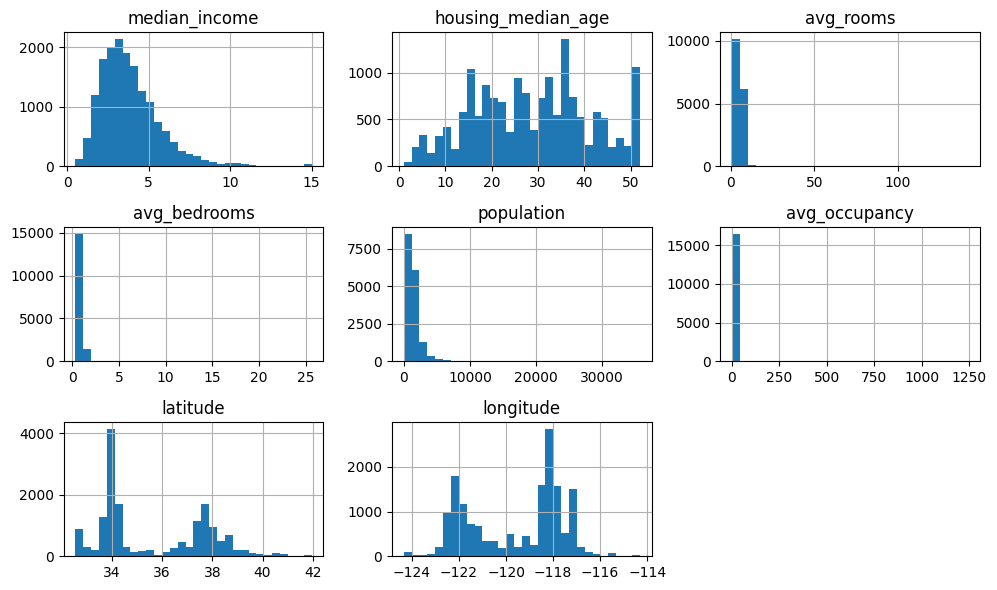

In [ ]:
import matplotlib.pyplot as plt

X_train.hist(figsize=(10, 6), bins=30)
plt.tight_layout()
plt.show()

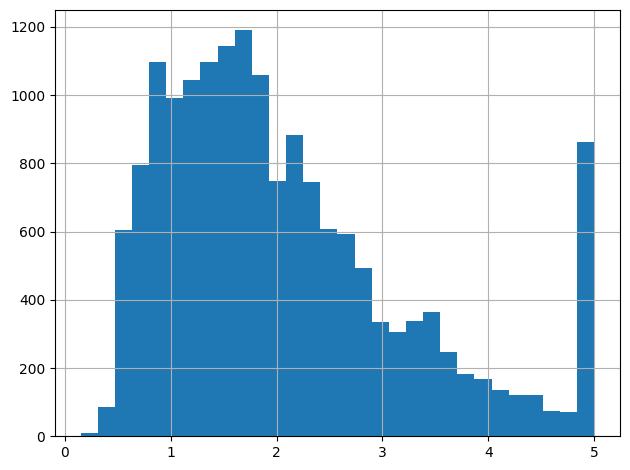

In [ ]:
y_train.hist(bins=30)
plt.tight_layout()
plt.show()

5. Identify at least two data issues that may affect modeling and explain why each is a concern.

6. For the issues you identified in Q5, could feature engineering help address any of them? If so, how? If not, what would you do instead?

7. Explain in your own words what each step in the code below is doing and why it may help modeling. Then implement the preprocessing using the **training and test data separately**.

```python
from sklearn.preprocessing import StandardScaler

data = [[0, 0], [0, 0], [1, 1], [1, 1]]

scaler = StandardScaler()
scaler.fit(data)

print(scaler.mean_)
# [0.5 0.5]

print(scaler.transform(data))
# [[-1. -1.]
#  [-1. -1.]
#  [ 1.  1.]
#  [ 1.  1.]]

print(scaler.transform([[2, 2]]))
# [[3. 3.]]
```

There are many concerns we discussed in the last lecture.

- The data appears to be top-coded (where values are capped at a maximum).
- Scale differences across features is another issue.
- Skewness is also a concern.

We cannot definitively solve all of these at once, so we *prioritize* scaling as the main concern for now. If model performance is not satisfactory, we can return to this list of concerns as part of our feedback loop. In other words, we are not ignoring the other concerns — we are simply **deferring** them.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)  # uses the mean/std learned from X_train

## Part 3 — Baseline Model

Build one baseline model using `LinearRegression`. Do not tune any hyperparameters (use default settings).

> **Note:** Most models have a `random_state` parameter for reproducibility. `LinearRegression` does not — it is a deterministic model with a closed-form solution, so the result is always the same regardless of random seed. Some models like `DecisionTreeClassifier` also behave deterministically by default, but still accept `random_state` for edge cases involving tie-breaking. When `random_state` is available, always set it.

```python
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

train_pred = baseline_model.predict(X_train_scaled)
test_pred  = baseline_model.predict(X_test_scaled)

train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse  = root_mean_squared_error(y_test,  test_pred)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
```

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

train_pred = baseline_model.predict(X_train_scaled)
test_pred  = baseline_model.predict(X_test_scaled)

train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse  = root_mean_squared_error(y_test,  test_pred)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")

Train RMSE: 0.7197
Test  RMSE: 0.7456


8. Evaluate the relationship between `train_rmse` and `test_rmse`.

- What does the difference between the two suggest about the model?
- Is the model likely underfitting, overfitting, or neither?
- Based on this result, what would be a reasonable next step to improve the model?

> **Note:** As discussed in class, it is very hard to conclude whether a model is overfitting or underfitting from a single metric alone. What we can observe is that training performance is typically better than test performance. The goal is to lower both, and to close the gap between them.

## Part 4 - Improvement

Consider **one improvement** to your baseline workflow.

Improvements generally fall into two categories: better preprocessing or a different model.

This is fundamentally a **data problem**. If you are not sure whether the data contains enough information to support the task, it is hard to know which direction to take. In general, improving preprocessing tends to give better rewards — but it is data-specific and often requires manual effort. We saw evidence of this in the last lecture.

One example of a feature engineering approach:

```python
df["bedrooms_ratio"] = df["avg_bedrooms"] / df["avg_rooms"]
```

If you go this route, be careful about the order of operations — **feature engineering must happen before scaling**. If you scale first and then create ratio features, the ratios will be computed on standardized values, which changes their meaning entirely.

In [ ]:
# Feature engineering — must happen before scaling
X_train_fe = X_train.copy()
X_test_fe  = X_test.copy()

X_train_fe["bedrooms_ratio"] = X_train_fe["avg_bedrooms"] / X_train_fe["avg_rooms"]
X_test_fe["bedrooms_ratio"]  = X_test_fe["avg_bedrooms"]  / X_test_fe["avg_rooms"]

# Re-fit scaler on the new training data and transform both sets
scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled  = scaler_fe.transform(X_test_fe)

# Fit model and evaluate
fe_model = LinearRegression()
fe_model.fit(X_train_fe_scaled, y_train)

fe_train_pred = fe_model.predict(X_train_fe_scaled)
fe_test_pred  = fe_model.predict(X_test_fe_scaled)

fe_train_rmse = root_mean_squared_error(y_train, fe_train_pred)
fe_test_rmse  = root_mean_squared_error(y_test,  fe_test_pred)

print(f"Train RMSE: {fe_train_rmse:.4f}")
print(f"Test  RMSE: {fe_test_rmse:.4f}")

Train RMSE: 0.7137
Test  RMSE: 0.7292


If you think the data contains enough information but performance did not meet your expectation, then your model may have too limited capacity. In that case, let's try a more flexible model — a decision tree. Since this is a regression problem, we use `DecisionTreeRegressor`.

```python
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train_scaled, y_train)

tree_train_pred = tree_model.predict(X_train_scaled)
tree_test_pred  = tree_model.predict(X_test_scaled)

tree_train_rmse = root_mean_squared_error(y_train, tree_train_pred)
tree_test_rmse  = root_mean_squared_error(y_test,  tree_test_pred)

print(f"Train RMSE: {tree_train_rmse:.4f}")
print(f"Test  RMSE: {tree_test_rmse:.4f}")
```

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train_scaled, y_train)

tree_train_pred = tree_model.predict(X_train_scaled)
tree_test_pred  = tree_model.predict(X_test_scaled)

tree_train_rmse = root_mean_squared_error(y_train, tree_train_pred)
tree_test_rmse  = root_mean_squared_error(y_test,  tree_test_pred)

print(f"Train RMSE: {tree_train_rmse:.4f}")
print(f"Test  RMSE: {tree_test_rmse:.4f}")

Train RMSE: 0.0000
Test  RMSE: 0.7028


A more flexible model will often give very good — sometimes extremely good — performance on training data, and test performance also tends to improve. However, if the gap between training and test RMSE grows dramatically, you need to worry about overfitting. For flexible models, tuning is not optional — it is a requirement.

The nice thing about tree models is that regularization is straightforward: we simply limit how deep the tree can grow. But before tuning, we should first check how deep the tree naturally grows without any constraint:

```python
unconstrained_tree = DecisionTreeRegressor(random_state=42)
unconstrained_tree.fit(X_train_scaled, y_train)

print(f"Actual tree depth: {unconstrained_tree.get_depth()}")
```

This gives us the upper bound for our search. There is no point searching beyond it. Now let's tune `max_depth` using `GridSearchCV`:

```python
from sklearn.model_selection import GridSearchCV

param_grid = {"max_depth": [5, 10, 15, 20, 25, 30, 34]}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_search.fit(X_train_scaled, y_train)

best_depth = grid_search.best_params_["max_depth"]
print(f"Best max_depth: {best_depth}")

tuned_tree = grid_search.best_estimator_
tuned_train_rmse = root_mean_squared_error(y_train, tuned_tree.predict(X_train_scaled))
tuned_test_rmse  = root_mean_squared_error(y_test,  tuned_tree.predict(X_test_scaled))

print(f"Train RMSE: {tuned_train_rmse:.4f}")
print(f"Test  RMSE: {tuned_test_rmse:.4f}")
```

> **How do we set `[5, 10, 15, 20, 25, 30, 34]`?** By default, `DecisionTreeRegressor` grows the tree until all leaves are pure — meaning it will keep splitting until it perfectly memorizes the training data. We first check the actual depth with `get_depth()`, which returned 34 in this case, and use that as the upper bound of our search grid.

In [ ]:
print(f"Actual tree depth: {tree_model.get_depth()}")

Actual tree depth: 34


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {"max_depth": [5, 10, 15, 20, 25, 30, 34]}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_search.fit(X_train_scaled, y_train)

best_depth = grid_search.best_params_["max_depth"]
print(f"Best max_depth: {best_depth}")

tuned_tree = grid_search.best_estimator_
tuned_train_rmse = root_mean_squared_error(y_train, tuned_tree.predict(X_train_scaled))
tuned_test_rmse  = root_mean_squared_error(y_test,  tuned_tree.predict(X_test_scaled))

print(f"Train RMSE: {tuned_train_rmse:.4f}")
print(f"Test  RMSE: {tuned_test_rmse:.4f}")

Best max_depth: 10
Train RMSE: 0.4700
Test  RMSE: 0.6442


9. Compare the improved model with the baseline. Is the improvement meaningful?


In [ ]:
import pandas as pd
comparison = pd.DataFrame({
    "workflow": ["Linear baseline", "Linear + bedrooms_ratio", "Tuned Decision Tree"],
    "train_rmse": [train_rmse, fe_train_rmse, tuned_train_rmse],
    "test_rmse":  [test_rmse,  fe_test_rmse,  tuned_test_rmse],
})
comparison["gap"] = comparison["test_rmse"] - comparison["train_rmse"]
comparison

,workflow,train_rmse,test_rmse,gap
0,Linear baseline,0.719676,0.745581,0.025906
1,Linear + bedrooms_ratio,0.713704,0.729206,0.015502
2,Tuned Decision Tree,0.469964,0.644242,0.174278


## Part 5 — Interpretation

Now report your results as a midpoint check. What are your findings so far?

10. What is a limitation of the decision tree model?

11. If you had more time, what would you try next and why?

> **Hint for Q10:** Think about what happens when you change the training data slightly — would the tree look the same? This is a property called **instability**. Also consider what kinds of relationships a single tree can and cannot capture well.

> **Hint for Q11:** Think about what naturally comes after a single tree. What if you used many trees instead of one? If you are convinced that the data contains enough information but the model still underperforms, it may be that a single tree does not have enough capacity. In other words, we may need a more complex or flexible model — and ensemble methods are a natural next step.